In [1]:
import torch
import glob
import os
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from pathlib import Path

from utils import functions as uf
from utils.model import DynamicMLP
from sklearn.model_selection import train_test_split


In [2]:
folder_path = './data/'
device = torch.device('cpu')

# Caricamento di tutti i file CSV presenti nella cartella
csv_files = glob.glob(os.path.join(folder_path, '*c000.csv'))
df_all = pd.concat((pd.read_csv(file, sep=";") for file in csv_files), ignore_index=True)
    
random_seed = 456
id_col = "user_id"

# Caricamento Forget set
forget_file_path = os.path.join(folder_path, 'forget_data.csv')
forget_df = pd.read_csv(forget_file_path)

# Estrazione ID da dimenticare
forget_ids = set(forget_df[id_col])

# Separazione netta tra Retain Set e Forget Set
retain_df = df_all[~df_all[id_col].isin(forget_ids)].reset_index(drop=True)
forget_df = df_all[df_all[id_col].isin(forget_ids)].reset_index(drop=True)

# Split Retain -> Train (80%) e Temp (20%)
train_df, temp_df = train_test_split(retain_df, test_size=0.20, random_state=random_seed)

# Split Temp -> Val (10%) e Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=random_seed)

print(f"Dataset Sizes -> Train (Retain): {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Forget: {len(forget_df)}")

# Salva gli ID di validazione richiesti per la submission
#val_df[[id_col]].to_csv('validation_ids.csv', index=False)

Dataset Sizes -> Train (Retain): 96558 | Val: 12070 | Test: 12070 | Forget: 9085


In [3]:
# 1. Estrazione delle matrici X e y per tutti i set dal dataframe corretto
X_train_raw, y_train, feature_cols, target_cols = uf.prepare_data(train_df, id_col=id_col, target_prefix='target__')
X_val_raw, y_val, _, _ = uf.prepare_data(val_df, id_col=id_col, target_prefix='target__')
X_test_raw, y_test, _, _ = uf.prepare_data(test_df, id_col=id_col, target_prefix='target__')
X_forget_raw, y_forget, _, _ = uf.prepare_data(forget_df, id_col=id_col, target_prefix='target__')

# 2. Imputazione coerente dei dati (fit su tutto df_all trasformato per coerenza con l'addestramento originale)
X_all_raw, _, _, _ = uf.prepare_data(df_all, id_col=id_col, target_prefix='target__')
imputer = SimpleImputer(strategy='median')
imputer.fit(X_all_raw)

X_train = imputer.transform(X_train_raw).astype(np.float32)
X_val = imputer.transform(X_val_raw).astype(np.float32)
X_test = imputer.transform(X_test_raw).astype(np.float32)
X_forget = imputer.transform(X_forget_raw).astype(np.float32)

# 3. Calcolo pos_weights sul Retain Train Set per la loss
pos_counts = np.sum(y_train, axis=0)
neg_counts = len(y_train) - pos_counts
pos_weights = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32, device=device)
pos_weights = pos_weights.clamp(min=0.1, max=100.0)
print(f"pos_weights: {pos_weights}")

# 4. Caricamento Artifact del modello pre-addestrato
artifact_path = Path('data') / 'model_artifact'
payload = uf.load_pickle(artifact_path)

state_dict = payload['state_dict']
architecture = payload['architecture']
best_params = payload['best_hyperparameters']

print("\n--- Saved Metadata ---")
print("Architecture parameters:", architecture)
print("Best Hyperparameters:", best_params)

model = DynamicMLP(
    input_dim=architecture['input_dim'],
    hidden_layers=architecture['hidden_layers'],
    num_outputs=architecture['num_outputs']
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel successfully reconstructed and weights loaded.")

DataFrame columns: ['ang_m_datediff_att_linea', 'ang_m_flag_mnp', 'ang_m_datediff_cessazione', 'ang_m_datediff_scad_sim', 'ang_m_cns_cre_res_per', 'ang_m_anz_linea', 'ang_m_datediff_mnp_in', 'ang_m_datediff_cam_prof', 'ang_m_datediff_mnp_out', 'ohe_ang_m_stato_linea_a', 'ohe_ang_m_stato_linea_c', 'ohe_ang_m_stato_linea_n', 'ohe_ang_m_stato_linea_s', 'ohe_ang_m_tipo_linea_fwa', 'ohe_ang_m_tipo_linea_pp', 'ohe_ang_m_tipo_linea_xt', 'ohe_ang_m_area_territoriale_altro_nd', 'ohe_ang_m_area_territoriale_c', 'ohe_ang_m_area_territoriale_ne', 'ohe_ang_m_area_territoriale_no', 'ohe_ang_m_area_territoriale_s', 'ohe_ang_m_pdv_canale_des_top_4_altro', 'ohe_ang_m_pdv_canale_des_top_4_grande_distribuzione', 'ohe_ang_m_pdv_canale_des_top_4_null', 'ohe_ang_m_pdv_canale_des_top_4_one_team', 'ohe_ang_m_pdv_canale_des_top_4_retail', 'ohe_ang_m_pdv_canale_des_top_4_tele_sales', 'ohe_ang_m_mnp_olo_prov_infrastrutturati', 'ohe_ang_m_mnp_olo_prov_mvno', 'ohe_ang_m_mnp_olo_prov_nd', 'ohe_ang_m_mnp_olo_dest_in

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import copy

# 1. Creiamo i DataLoader per Forget e Retain
batch_size = 256

# Prepareshing dei PyTorch Tensor
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
forget_dataset = TensorDataset(torch.tensor(X_forget, dtype=torch.float32), torch.tensor(y_forget, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
forget_loader = DataLoader(forget_dataset, batch_size=batch_size, shuffle=True)

# 2. Definiamo la Loss Function con i pos_weights calcolati in precedenza
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# Gradeint ascent method

In [ ]:


# 3. Prepariamo il modello per l'unlearning (lavoriamo su una copia per non sovrascrivere l'originale)
unlearned_model = copy.deepcopy(model)
unlearned_model.train()

# Optimizer (un learning rate basso è fondamentale per non rompere i pesi)
lr = 1e-4
optimizer = torch.optim.Adam(unlearned_model.parameters(), lr=lr)

# Coefficienti di bilanciamento
alpha = 1.0  # Peso per il Gradient Ascent (Forget)
beta = 1.0   # Peso per il Gradient Descent (Retain)

epochs = 1   # Spesso 1-3 epoche bastano per l'unlearning senza distruggere il modello

# Loop di Unlearning
train_iter = iter(train_loader)

for epoch in range(epochs):
    total_loss = 0.0
    for x_f, y_f in forget_loader:
        x_f, y_f = x_f.to(device), y_f.to(device)
        
        # Prendi un batch dal Retain set
        try:
            x_r, y_r = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x_r, y_r = next(train_iter)
            
        x_r, y_r = x_r.to(device), y_r.to(device)
        
        optimizer.zero_grad()
        
        # Loss sul Forget Set
        out_f = unlearned_model(x_f)
        loss_forget = criterion(out_f, y_f)
        
        # Loss sul Retain Set
        out_r = unlearned_model(x_r)
        loss_retain = criterion(out_r, y_r)
        
        # Combined Loss: Sottraiamo la loss di forget (Gradient Ascent) e sommiamo la loss di retain (Gradient Descent)
        combined_loss = - alpha * loss_forget + beta * loss_retain
        
        combined_loss.backward()
        optimizer.step()
        
        total_loss += combined_loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} - Loss combinata: {total_loss / len(forget_loader):.4f}")

# ---------------------------------------------------------
# FASE 2: FINE-TUNING SOLO SUL RETAIN SET
# ---------------------------------------------------------
print("\n--- FASE 2: Inizio Fine-Tuning sul Retain Set ---")

# Learning rate molto basso/conservativo per non re-imparare il Forget set
finetune_lr = 5e-4
finetune_epochs = 5  # Di solito 1-3 epoche bastano per riassestare il modello

optimizer_finetune = torch.optim.Adam(
    unlearned_model.parameters(), lr=finetune_lr
)

for epoch in range(finetune_epochs):
  total_ft_loss = 0.0
  for x_r, y_r in train_loader:
    x_r, y_r = x_r.to(device), y_r.to(device)

    optimizer_finetune.zero_grad()

    # Calcolo Loss ESCLUSIVAMENTE sui dati di Retain
    out_r = unlearned_model(x_r)
    loss_ft = criterion(out_r, y_r)

    loss_ft.backward()
    optimizer_finetune.step()

    total_ft_loss += loss_ft.item()

  avg_ft_loss = total_ft_loss / len(train_loader)
  print(
      f"Fine-Tuning Epoch {epoch+1}/{finetune_epochs} - Retain Loss:"
      f" {avg_ft_loss:.4f}"
  )

unlearned_model.eval()
print("\nUnlearning e Fine-Tuning completati con successo!")


Epoch 1/1 - Loss combinata: 0.0106

--- FASE 2: Inizio Fine-Tuning sul Retain Set ---
Fine-Tuning Epoch 1/5 - Retain Loss: 0.7150
Fine-Tuning Epoch 2/5 - Retain Loss: 0.7087
Fine-Tuning Epoch 3/5 - Retain Loss: 0.7078
Fine-Tuning Epoch 4/5 - Retain Loss: 0.7082
Fine-Tuning Epoch 5/5 - Retain Loss: 0.7077

Unlearning e Fine-Tuning completati con successo!


# Fischer

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import copy
# =========================================================
# FASE 1: CALCOLO DELL'INFORMAZIONE DI FISHER SUL RETAIN SET
# =========================================================
print("\n--- Calcolo dell'Informazione di Fisher sul Retain Set ---")

# Utilizziamo una copia del modello originale già caricato
fisher_model = copy.deepcopy(model)
fisher_model.eval()

# Inizializzazione contenitore per il quadrato dei gradienti (Fisher Matrix Diagonale)
fisher_diag = {
    name: torch.zeros_like(param) 
    for name, param in fisher_model.named_parameters() 
    if param.requires_grad
}

num_samples = 0

# Accumulo dei gradienti al quadrato sul train_loader (Retain Set)
for x_b, y_b in train_loader:
    x_b, y_b = x_b.to(device), y_b.to(device)
    batch_dim = x_b.size(0)
    num_samples += batch_dim
    
    fisher_model.zero_grad()
    out = fisher_model(x_b)
    loss = criterion(out, y_b)
    loss.backward()
    
    with torch.no_grad():
        for name, param in fisher_model.named_parameters():
            if param.requires_grad and param.grad is not None:
                fisher_diag[name] += (param.grad ** 2) * batch_dim

# Media dell'Informazione di Fisher
for name in fisher_diag:
    fisher_diag[name] /= num_samples


# =========================================================
# FASE 2: INIEZIONE DI RUMORE DI FISHER (UNLEARNING)
# =========================================================
print("\n--- Iniezione di Rumore di Fisher (Selective Amnesia) ---")

alpha_fisher = 1e-5  # Scala del rumore conservativa
damping = 1e-5       # Damping elevato per stabilità (evita divisioni per zero)

with torch.no_grad():
    for name, param in fisher_model.named_parameters():
        if param.requires_grad:
            # Protezione: Applichiamo il rumore SOLO ai pesi (weight) e NON a BatchNorm o Bias
            if 'weight' in name and 'bn' not in name and 'batch' not in name:
                variance = alpha_fisher / torch.sqrt(fisher_diag[name] + damping)
                std_dev = torch.sqrt(variance)
                
                noise = torch.randn_like(param) * std_dev
                param.add_(noise)

print("Fisher Forgetting applicato con successo!")


# =========================================================
# FASE 3: FINE-TUNING DI RICALIBRAZIONE SUL RETAIN SET
# =========================================================
fisher_model, best_val_p10 = uf.run_finetune_with_p10(
    model=fisher_model,
    train_loader=train_loader,
    X_val=X_val,
    y_val=y_val,
    device=device,
    uf_module=uf,
    epochs=2,
    lr=5e-4
)


# =========================================================
# FASE 4: CREAZIONE SUBMISSION BLINDATA
# =========================================================

submission_path = uf.export_submission(
    model=fisher_model,
    val_df=val_df,
    id_col=id_col,
    architecture=architecture,
    best_params=best_params,
    payload=payload,
    version="V17",
    group_name="NoWINDtoday"
)


--- Calcolo dell'Informazione di Fisher sul Retain Set ---

--- Iniezione di Rumore di Fisher (Selective Amnesia) ---
Fisher Forgetting applicato con successo!

--- Inizio Fine-Tuning sul Retain Set (2 epoche) ---
Epoch 1/2 | Retain Loss: 0.1052 | Train P@10: 0.0381 | Val P@10: 0.0409
Epoch 2/2 | Retain Loss: 0.0804 | Train P@10: 0.0414 | Val P@10: 0.0411
✅ Caricati i pesi dell'epoca con la migliore Val Precision@10: 0.0411
--- Check Dtypes dello State Dict ---
Tensori Float32: 14 | Tensori Float64: 0
✅ Perfetto: NESSUN tensore a 64-bit presente! Tutto in Float32.

✅ Cartella 'submissions\NoWINDtoday_V17' creata con successo e pronta per l'invio!


In [10]:
import torch

def compare_state_dicts(state_dict_1, state_dict_2):
    keys_1 = set(state_dict_1.keys())
    keys_2 = set(state_dict_2.keys())
    
    # 1. Verifica presenza chiavi
    missing_in_2 = keys_1 - keys_2
    missing_in_1 = keys_2 - keys_1
    
    if missing_in_2 or missing_in_1:
        print("❌ Discrepanza nelle chiavi!")
        if missing_in_2:
            print(f"  - Chiavi presenti solo nel primo: {missing_in_2}")
        if missing_in_1:
            print(f"  - Chiavi presenti solo nel secondo: {missing_in_1}")
        return False

    print("✅ Le chiavi dei due modelli combaciano perfettamente.\n")

    # 2. Confronto valore dei tensor
    identical_params = []
    different_params = []

    for key in keys_1:
        # Convertiamo sempre in float per evitare il RuntimeError su interi/Long
        tensor1 = state_dict_1[key].cpu().float()
        tensor2 = state_dict_2[key].cpu().float()
        
        # Verifica se i valori sono uguali
        if torch.equal(tensor1, tensor2):
            identical_params.append(key)
        else:
            diff = torch.abs(tensor1 - tensor2)
            max_diff = torch.max(diff).item()
            mean_diff = torch.mean(diff).item()  # Ora funziona perfettamente su tutti i layer!
            different_params.append((key, max_diff, mean_diff))

    # Stampa i risultati
    print(f"Parametri IDENTICI: {len(identical_params)} / {len(keys_1)}")
    print(f"Parametri MODIFICATI: {len(different_params)} / {len(keys_1)}\n")

    if different_params:
        print("Dettaglio parametri modificati (Layer | Max Diff | Mean Diff):")
        for key, max_d, mean_d in different_params:
            print(f" - {key:<45} | Max: {max_d:.6e} | Mean: {mean_d:.6e}")
    else:
        print("🎉 I due modelli sono al 100% uguali!")

    return len(different_params) == 0

# --- ESECUZIONE ---
are_identical = compare_state_dicts(payload['state_dict'], fisher_model.state_dict())

✅ Le chiavi dei due modelli combaciano perfettamente.

Parametri IDENTICI: 1 / 16
Parametri MODIFICATI: 15 / 16

Dettaglio parametri modificati (Layer | Max Diff | Mean Diff):
 - net.1.weight                                  | Max: 1.472052e-01 | Mean: 4.198084e-02
 - net.1.running_mean                            | Max: 5.354724e+09 | Mean: 1.555959e+09
 - net.1.bias                                    | Max: 7.215771e-02 | Mean: 2.453369e-02
 - net.4.weight                                  | Max: 2.476865e-01 | Mean: 6.424457e-02
 - net.4.running_mean                            | Max: 8.316879e-01 | Mean: 2.921019e-01
 - net.3.bias                                    | Max: 1.669139e-03 | Mean: 2.319987e-04
 - net.4.running_var                             | Max: 1.888826e+00 | Mean: 5.687779e-01
 - net.4.num_batches_tracked                     | Max: 3.780000e+02 | Mean: 3.780000e+02
 - net.0.weight                                  | Max: 2.446889e-01 | Mean: 4.503437e-02
 - net.3.weigh

# KL Divergence

In [7]:
# =========================================================
# FASE 1: UNLEARNING TRAMITE KL DIVERGENCE 
# (Prende il posto del ciclo di Fisher!)
# =========================================================
print("\n--- FASE 1: Unlearning con KL Divergence ---")

unlearned_model = copy.deepcopy(model)
unlearned_model.train()

# Model originale congelato (serve da ancora per il Retain)
orig_model = copy.deepcopy(model)
orig_model.eval()
for param in orig_model.parameters():
    param.requires_grad = False

optimizer_unlearn = torch.optim.Adam(unlearned_model.parameters(), lr=1e-4)

# Iperparametri di bilanciamento
alpha = 1.0  # Peso Retain (mantiene la memoria)
beta = 0.3   # Peso Forget (forza l'amnesia verso 0.5)

train_iter = iter(train_loader)

for epoch in range(1): # 1 o 2 epoche bastano
    for x_f, y_f in forget_loader:
        x_f = x_f.to(device)
        
        # Prendi batch dal Retain
        try:
            x_r, _ = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x_r, _ = next(train_iter)
        x_r = x_r.to(device)
        
        optimizer_unlearn.zero_grad()
        
        # 1. RETAIN: Mantiieni gli output vicini al modello originale
        with torch.no_grad():
            logits_orig_r = orig_model(x_r)
        logits_unlearned_r = unlearned_model(x_r)
        loss_retain = uf.binary_kl_divergence(logits_orig_r, logits_unlearned_r)
        
        # 2. FORGET: Spingi verso la massima incertezza (logit 0.0 -> p = 0.5)
        logits_unlearned_f = unlearned_model(x_f)
        uniform_target_f = torch.zeros_like(logits_unlearned_f)
        loss_forget = uf.binary_kl_divergence(uniform_target_f, logits_unlearned_f)
        
        # Loss combinata
        total_loss = alpha * loss_retain + beta * loss_forget
        total_loss.backward()
        optimizer_unlearn.step()

print("Unlearning con KL completato!")


# =========================================================
# FASE 2: FINE-TUNING FINALE SUL RETAIN SET (Rimane invariata!)
# =========================================================
print("\n--- FASE 2: Fine-Tuning di Ricalibrazione sul Retain Set ---")

unlearned_model, best_val_p10 = uf.run_finetune_with_p10(
    model=unlearned_model,
    train_loader=train_loader,
    X_val=X_val,
    y_val=y_val,
    device=device,
    uf_module=uf,
    epochs=2,
    lr=3e-4
)

submission_path = uf.export_submission(
    model=unlearned_model,
    val_df=val_df,
    id_col=id_col,
    architecture=architecture,
    best_params=best_params,
    payload=payload,
    version="V18",
    group_name="NoWINDtoday"
)


--- FASE 1: Unlearning con KL Divergence ---
Unlearning con KL completato!

--- FASE 2: Fine-Tuning di Ricalibrazione sul Retain Set ---

--- Inizio Fine-Tuning sul Retain Set (2 epoche) ---
Epoch 1/2 | Retain Loss: 0.1229 | Train P@10: 0.0355 | Val P@10: 0.0402
Epoch 2/2 | Retain Loss: 0.0817 | Train P@10: 0.0410 | Val P@10: 0.0411
✅ Caricati i pesi dell'epoca con la migliore Val Precision@10: 0.0411
--- Check Dtypes dello State Dict ---
Tensori Float32: 14 | Tensori Float64: 0
✅ Perfetto: NESSUN tensore a 64-bit presente! Tutto in Float32.

✅ Cartella 'submissions\NoWINDtoday_V18' creata con successo e pronta per l'invio!


# Submission

In [19]:
import time
import os
import shutil

# --- CONFIGURAZIONE ---
GROUP_NAME = "NoWINDtoday" # Cambia con il nome del tuo gruppo
VERSION = "V14"
SUBMISSION_DIR = f"submissions/{GROUP_NAME}_{VERSION}"

execution_time_sec = 4

# 2. CREAZIONE DELLA CARTELLA SUBMISSION
os.makedirs(SUBMISSION_DIR, exist_ok=True)

# 3. CREAZIONE DI execution_time.txt
with open(os.path.join(SUBMISSION_DIR, 'execution_time.txt'), 'w') as f:
    f.write(str(execution_time_sec))

val_ids = val_df[[id_col]].dropna().copy()
val_ids[id_col] = val_ids[id_col].astype(int)

val_ids.to_csv(
    os.path.join(SUBMISSION_DIR, 'validation_ids.csv'),
    index=False,
    header=True,
    encoding='utf-8'
)

# 5. SALVATAGGIO DEL NUOVO model_artifact
# Manteniamo la stessa struttura del payload originale aggiornando lo state_dict

state_dict_cpu = {k: v.cpu() for k, v in unlearned_model.state_dict().items()}

new_payload = {
    'state_dict': state_dict_cpu,
    'architecture': architecture,
    'best_hyperparameters': best_params,
    'model_class_source': payload['model_class_source'] if 'model_class_source' in payload else None
}

artifact_save_path = os.path.join(SUBMISSION_DIR, 'model_artifact')
with open(os.path.join(SUBMISSION_DIR, 'model_artifact'), 'wb') as f:
    uf.pickle.dump(new_payload, f)
print(f"\nCartella '{SUBMISSION_DIR}' creata con successo e pronta per il caricamento!")


Cartella 'submissions/NoWINDtoday_V14' creata con successo e pronta per il caricamento!


# Retraining from scratch

In [22]:
import time
import os
import shutil
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from torch.utils.data import DataLoader, TensorDataset

start_time = time.time()

# 0. Impostazione del Random Seed per riproducibilità
random_seed = 456
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# 1. Isolamento completo del Retain Set e pulizia imputer (ZERO Data Leakage dal Forget Set)
X_retain_raw, y_retain, feature_cols, target_cols = uf.prepare_data(
    retain_df, id_col=id_col, target_prefix='target__'
)

imputer_scratch = SimpleImputer(strategy='median')
X_retain_scratch = imputer_scratch.fit_transform(X_retain_raw).astype(np.float32)

# 2. Creazione DataLoader su TUTTO il Retain Set
batch_size = best_params.get('batch_size', 256) if 'best_params' in locals() else 256
retain_dataset = TensorDataset(
    torch.as_tensor(X_retain_scratch, dtype=torch.float32),
    torch.as_tensor(y_retain, dtype=torch.float32)
)
retain_loader = DataLoader(retain_dataset, batch_size=batch_size, shuffle=True)

# 3. Pos weights ricalcolati ed esclusivi per il retain set (clamp max=10.0)
pos_counts = np.sum(y_retain, axis=0)
neg_counts = len(y_retain) - pos_counts
pos_weights = torch.tensor(
    neg_counts / (pos_counts + 1e-6),
    dtype=torch.float32,
    device=device
).clamp(min=0.1, max=10.0)

#criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights).to(device)

# 4. Inizializzazione della rete EX NOVO
retrained_model = DynamicMLP(
    input_dim=architecture['input_dim'],
    hidden_layers=architecture['hidden_layers'],
    num_outputs=architecture['num_outputs']
).to(device)

lr = 0.001
epochs = 50
optimizer = torch.optim.Adam(retrained_model.parameters(), lr=lr)

print(f"\n--- Inizio Retraining da Zero sul Retain Set ({epochs} epoche) ---")

retrained_model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for x_b, y_b in retain_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        out = retrained_model(x_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    mean_loss = total_loss / len(retain_loader)
    
    # Log ogni 5 epoche o all'ultima
    if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Loss: {mean_loss:.4f}")

retrained_model.eval()
print("\nRetraining da zero completato!")

from sklearn.metrics import f1_score
import numpy as np

y_probs = retrained_model.predict_proba(X_retain_scratch)

# Trova la soglia migliore classe per classe
best_thresholds = []
best_f1_scores = []

for i in range(y_retain.shape[1]):
    best_thresh = 0.5
    best_f1 = 0.0
    for thresh in np.arange(0.1, 0.9, 0.05):
        pred_i = (y_probs[:, i] > thresh).astype(int)
        score = f1_score(y_retain[:, i], pred_i, zero_division=0)
        
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    best_thresholds.append(best_thresh)
    best_f1_scores.append(best_f1)

print("Soglie ottimali per classe:", best_thresholds)
print(f"F1-Score Medio Macro con soglie personalizzate: {np.mean(best_f1_scores):.4f}")

# Calcolo del tempo reale di esecuzione
execution_time_sec = int(time.time() - start_time)

# --- CREAZIONE SUBMISSION ---
GROUP_NAME = "NoWINDtoday"
VERSION = "V11"
SUBMISSION_DIR = f"submissions/{GROUP_NAME}_{VERSION}"

os.makedirs(SUBMISSION_DIR, exist_ok=True)

# 1. execution_time.txt
with open(os.path.join(SUBMISSION_DIR, 'execution_time.txt'), 'w') as f:
    f.write(str(execution_time_sec))

# 2. validation_ids.csv
val_ids = val_df[[id_col]].dropna().copy()
val_ids[id_col] = val_ids[id_col].astype(int)
val_ids.to_csv(
    os.path.join(SUBMISSION_DIR, 'validation_ids.csv'),
    index=False,
    header=True,
    encoding='utf-8'
)

# 3. model_artifact
state_dict_cpu = {k: v.detach().cpu() for k, v in retrained_model.state_dict().items()}

new_payload = {
    'state_dict': state_dict_cpu,
    'architecture': architecture,
    'best_hyperparameters': {
        'lr': lr,
        'epochs': epochs,
        'batch_size': batch_size
    },
    'model_class_source': payload.get('model_class_source', None)
}

with open(os.path.join(SUBMISSION_DIR, 'model_artifact'), 'wb') as f:
    uf.pickle.dump(new_payload, f)

print(f"\nCartella '{SUBMISSION_DIR}' creata con successo! Tempo esecuzione: {execution_time_sec}s")
from sklearn.metrics import roc_auc_score, classification_report

# Predizioni di probabilità con la funzione integrata nel tuo DynamicMLP
y_probs = retrained_model.predict_proba(X_retain_scratch)

# ROC-AUC Medio (Macro o Weighted per multi-target)
macro_auc = roc_auc_score(y_retain, y_probs, average='macro')
print(f"Train ROC-AUC: {macro_auc:.4f}")

# F1-Score con soglia 0.5
y_pred = (y_probs > 0.5).astype(int)
print(classification_report(y_retain, y_pred, zero_division=0))

DataFrame columns: ['ang_m_datediff_att_linea', 'ang_m_flag_mnp', 'ang_m_datediff_cessazione', 'ang_m_datediff_scad_sim', 'ang_m_cns_cre_res_per', 'ang_m_anz_linea', 'ang_m_datediff_mnp_in', 'ang_m_datediff_cam_prof', 'ang_m_datediff_mnp_out', 'ohe_ang_m_stato_linea_a', 'ohe_ang_m_stato_linea_c', 'ohe_ang_m_stato_linea_n', 'ohe_ang_m_stato_linea_s', 'ohe_ang_m_tipo_linea_fwa', 'ohe_ang_m_tipo_linea_pp', 'ohe_ang_m_tipo_linea_xt', 'ohe_ang_m_area_territoriale_altro_nd', 'ohe_ang_m_area_territoriale_c', 'ohe_ang_m_area_territoriale_ne', 'ohe_ang_m_area_territoriale_no', 'ohe_ang_m_area_territoriale_s', 'ohe_ang_m_pdv_canale_des_top_4_altro', 'ohe_ang_m_pdv_canale_des_top_4_grande_distribuzione', 'ohe_ang_m_pdv_canale_des_top_4_null', 'ohe_ang_m_pdv_canale_des_top_4_one_team', 'ohe_ang_m_pdv_canale_des_top_4_retail', 'ohe_ang_m_pdv_canale_des_top_4_tele_sales', 'ohe_ang_m_mnp_olo_prov_infrastrutturati', 'ohe_ang_m_mnp_olo_prov_mvno', 'ohe_ang_m_mnp_olo_prov_nd', 'ohe_ang_m_mnp_olo_dest_in

In [23]:
from sklearn.metrics import roc_auc_score, classification_report

# Predizioni di probabilità con la funzione integrata nel tuo DynamicMLP
y_probs = retrained_model.predict_proba(X_retain_scratch)

# ROC-AUC Medio (Macro o Weighted per multi-target)
macro_auc = roc_auc_score(y_retain, y_probs, average='macro')
print(f"Train ROC-AUC: {macro_auc:.4f}")

# F1-Score con soglia 0.5
y_pred = (y_probs > 0.5).astype(int)
print(classification_report(y_retain, y_pred, zero_division=0))

Train ROC-AUC: 0.8696
              precision    recall  f1-score   support

           0       0.12      0.71      0.21      3679
           1       0.00      0.00      0.00       321
           2       0.00      0.00      0.00       105
           3       0.11      0.39      0.17      2420
           4       0.11      0.16      0.13      1807
           5       0.12      0.04      0.06      1615
           6       0.13      0.59      0.21      3218
           7       0.11      0.64      0.19      3992
           8       0.13      0.52      0.21      3279
           9       0.17      0.91      0.28      6288
          10       0.11      0.56      0.18      2601
          11       0.14      0.83      0.24      5289
          12       0.14      0.81      0.23      5093
          13       0.14      0.53      0.22      2414
          14       0.14      0.30      0.20      1892
          15       0.10      0.23      0.14      2364
          16       0.12      0.52      0.19      3668
     

Min prob: 0.0000 | Max prob: 0.9873
Media prob: 0.1621 | Dev.Std: 0.2056


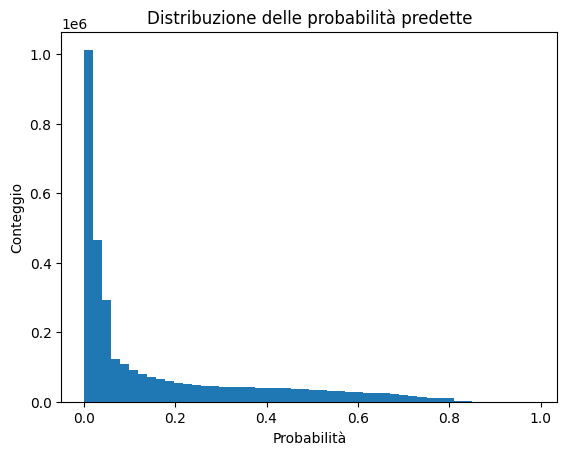

In [24]:
import matplotlib.pyplot as plt

# Stampa le statistiche di base delle probabilità
print(f"Min prob: {y_probs.min():.4f} | Max prob: {y_probs.max():.4f}")
print(f"Media prob: {y_probs.mean():.4f} | Dev.Std: {y_probs.std():.4f}")

# Istogramma delle predizioni
plt.hist(y_probs.flatten(), bins=50)
plt.title("Distribuzione delle probabilità predette")
plt.xlabel("Probabilità")
plt.ylabel("Conteggio")
plt.show()

# Prove

Artifact successfully loaded.
DataFrame columns: ['ang_m_datediff_att_linea', 'ang_m_flag_mnp', 'ang_m_datediff_cessazione', 'ang_m_datediff_scad_sim', 'ang_m_cns_cre_res_per', 'ang_m_anz_linea', 'ang_m_datediff_mnp_in', 'ang_m_datediff_cam_prof', 'ang_m_datediff_mnp_out', 'ohe_ang_m_stato_linea_a', 'ohe_ang_m_stato_linea_c', 'ohe_ang_m_stato_linea_n', 'ohe_ang_m_stato_linea_s', 'ohe_ang_m_tipo_linea_fwa', 'ohe_ang_m_tipo_linea_pp', 'ohe_ang_m_tipo_linea_xt', 'ohe_ang_m_area_territoriale_altro_nd', 'ohe_ang_m_area_territoriale_c', 'ohe_ang_m_area_territoriale_ne', 'ohe_ang_m_area_territoriale_no', 'ohe_ang_m_area_territoriale_s', 'ohe_ang_m_pdv_canale_des_top_4_altro', 'ohe_ang_m_pdv_canale_des_top_4_grande_distribuzione', 'ohe_ang_m_pdv_canale_des_top_4_null', 'ohe_ang_m_pdv_canale_des_top_4_one_team', 'ohe_ang_m_pdv_canale_des_top_4_retail', 'ohe_ang_m_pdv_canale_des_top_4_tele_sales', 'ohe_ang_m_mnp_olo_prov_infrastrutturati', 'ohe_ang_m_mnp_olo_prov_mvno', 'ohe_ang_m_mnp_olo_prov_n